# Notebook 08: Results Visualization
Generates publication-quality charts for the paper and public site, including Panel VAR Impulse Response Functions (IRFs), Event-Study continuous dosage paths, falsification comparisons, and exploratory spline threshold curves.

### Important Project Safety Notice

Before executing or citing the findings in this notebook, please read the public guidance on what this project is and is not claiming:  

[docs/not_saying.md](../docs/not_saying.md) - *What This Theory Is NOT Claiming*

## 1. Library Imports & Setup
Set up plotting styles and import necessary packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR

# Set style for publication quality
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 150
})

df = pd.read_csv('../data/processed/state_year_panel.csv')
print('Data loaded. Shape:', df.shape)

Data loaded. Shape: (765, 59)


## 2. Impulse-Response Function (IRF)
We estimate the GMM-style Panel VAR on Helmert-transformed variables, then trace the impulse response functions with asymptotic confidence intervals.

C:\Users\admir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


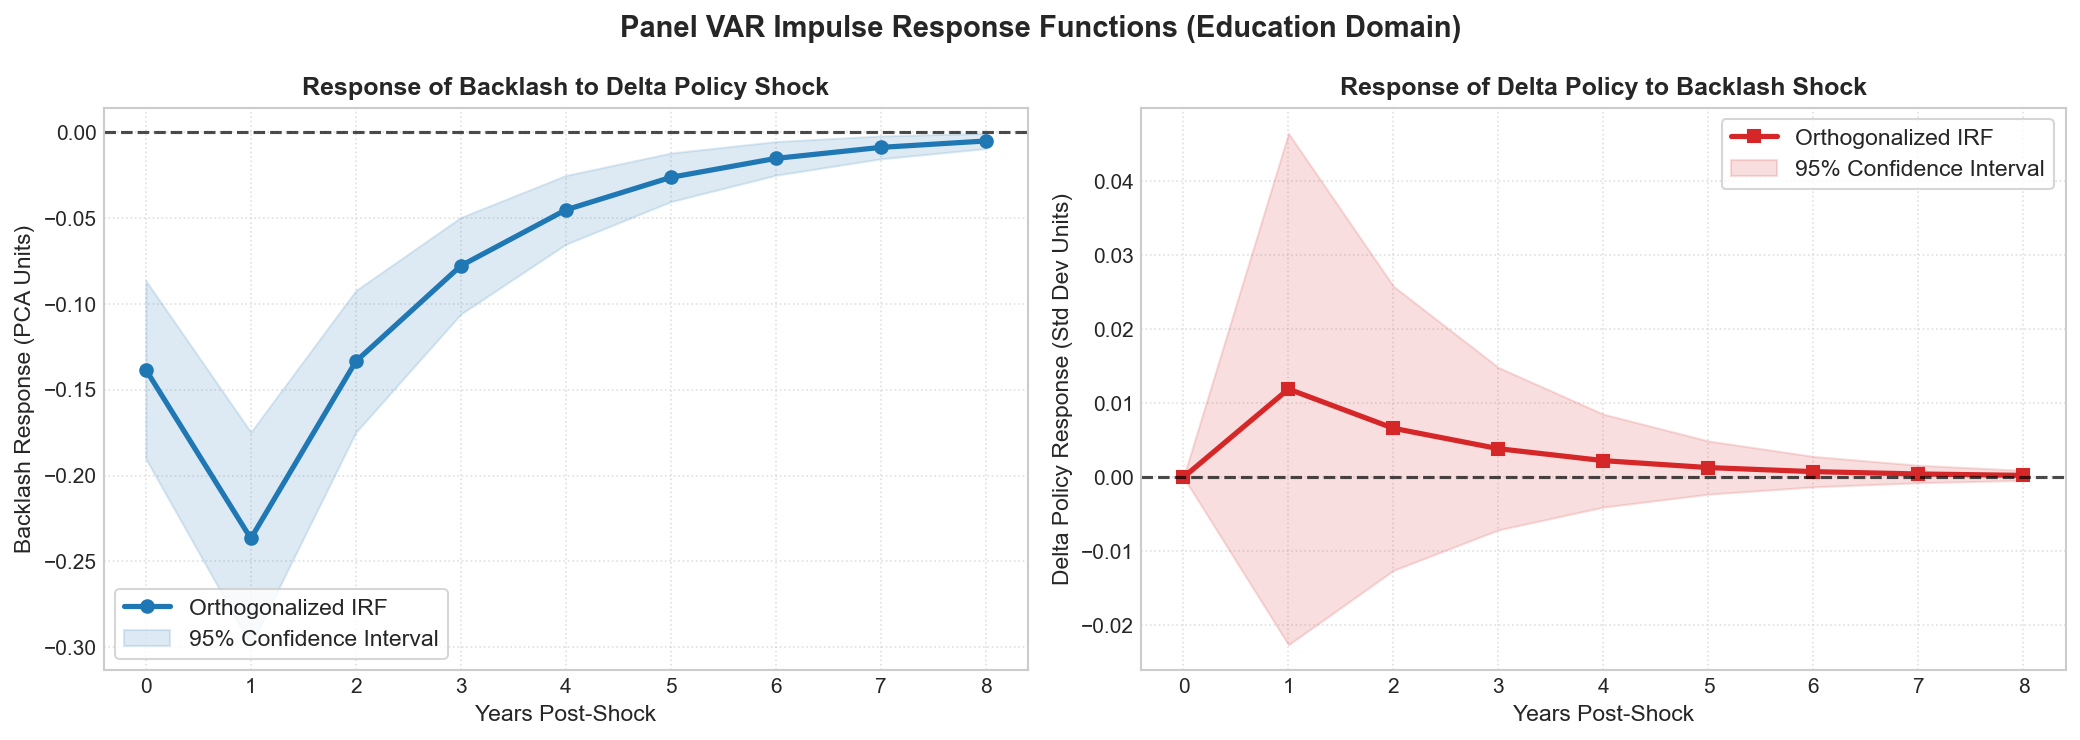

In [2]:
def helmert_transform(df, cols):
    df_transformed = []
    for state, group in df.groupby('state'):
        group = group.sort_values('year').copy()
        T = len(group)
        for t in range(T - 1):
            row = group.iloc[t].copy()
            for col in cols:
                forward_vals = group.iloc[t+1:][col].values
                mean_forward = np.mean(forward_vals)
                scale = np.sqrt((T - t - 1) / (T - t))
                row[col] = scale * (group.iloc[t][col] - mean_forward)
            df_transformed.append(row)
    return pd.DataFrame(df_transformed)

# 1. Transform variables for education panel
df_var_input = df[['state', 'year', 'delta_policy', 'backlash']].dropna().copy()
df_helmert = helmert_transform(df_var_input, ['delta_policy', 'backlash'])

# 2. Fit VAR(1)
var_model = VAR(df_helmert[['delta_policy', 'backlash']])
var_results = var_model.fit(maxlags=1)
irf = var_results.irf(8)

# 3. Extract and plot IRFs
steps = np.arange(9)
resp_b_to_p = irf.orth_irfs[:, 1, 0]
se_b_to_p = irf.stderr(orth=True)[:, 1, 0]

resp_p_to_b = irf.orth_irfs[:, 0, 1]
se_p_to_b = irf.stderr(orth=True)[:, 0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Policy Shock -> Backlash
axes[0].plot(steps, resp_b_to_p, color='#1f77b4', lw=2.5, marker='o', label='Orthogonalized IRF')
axes[0].fill_between(steps, resp_b_to_p - 1.96 * se_b_to_p, resp_b_to_p + 1.96 * se_b_to_p, color='#1f77b4', alpha=0.15, label='95% Confidence Interval')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Response of Backlash to Delta Policy Shock', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Years Post-Shock', fontsize=11)
axes[0].set_ylabel('Backlash Response (PCA Units)', fontsize=11)
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Backlash Shock -> Policy
axes[1].plot(steps, resp_p_to_b, color='#d62728', lw=2.5, marker='s', label='Orthogonalized IRF')
axes[1].fill_between(steps, resp_p_to_b - 1.96 * se_p_to_b, resp_p_to_b + 1.96 * se_p_to_b, color='#d62728', alpha=0.15, label='95% Confidence Interval')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Response of Delta Policy to Backlash Shock', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Years Post-Shock', fontsize=11)
axes[1].set_ylabel('Delta Policy Response (Std Dev Units)', fontsize=11)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Panel VAR Impulse Response Functions (Education Domain)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 3. Event-Study Dosage Plot
Plot the coefficients for the continuous event-study dosage model to show the dynamic effect of pre-treatment policy intensity dosage on backlash.

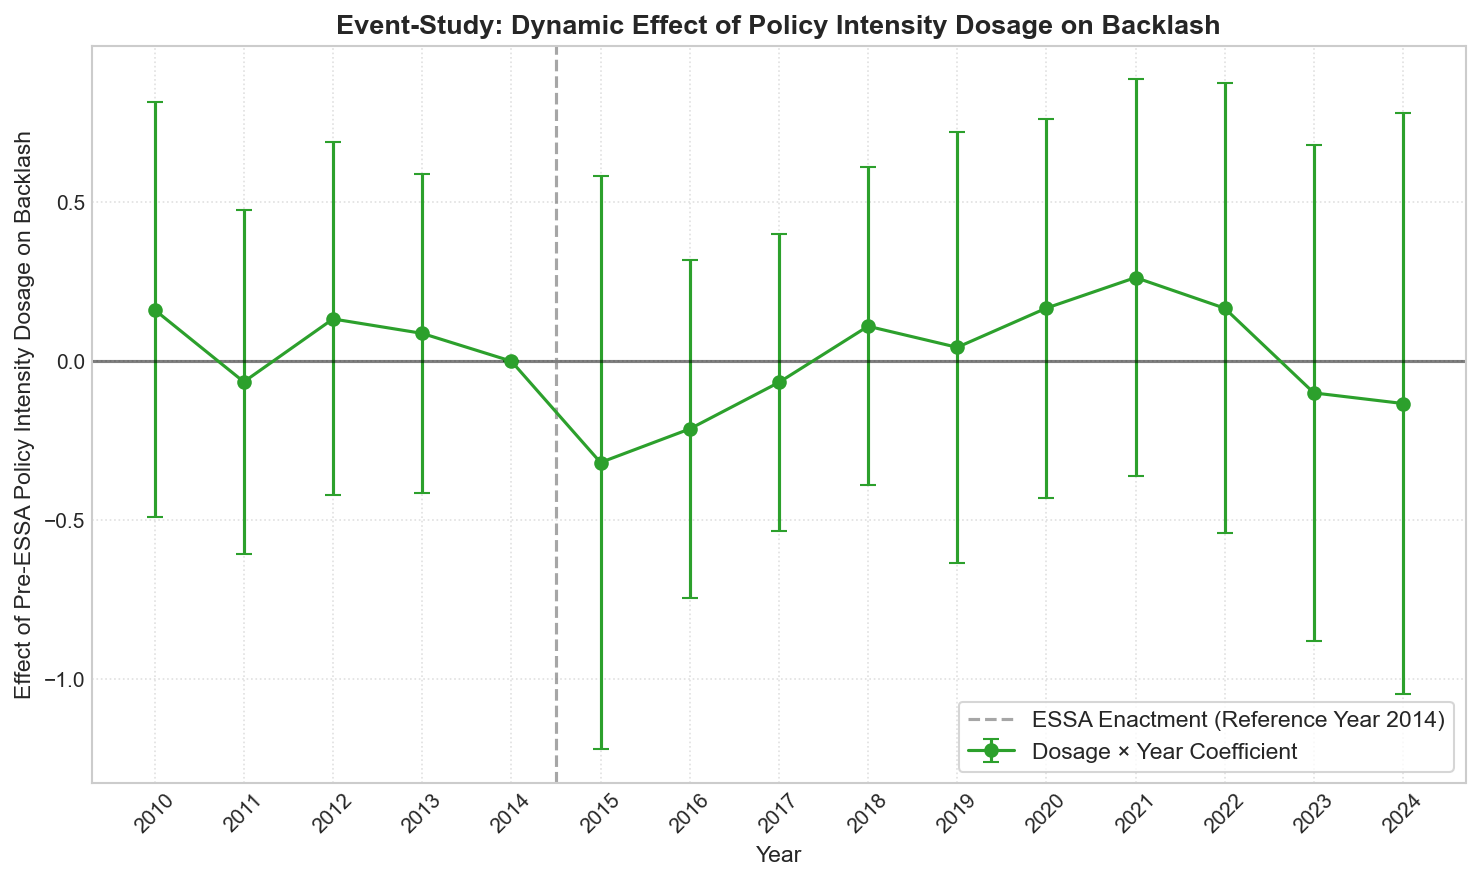

In [3]:
# 1. Calculate continuous dosage (average pre-ESSA policy intensity 2010-2014)
pre_essa_mean = df[df['year'] <= 2014].groupby('state')['policy_intensity'].mean().reset_index()
pre_essa_mean.rename(columns={'policy_intensity': 'pre_essa_dosage'}, inplace=True)
df_event = df.merge(pre_essa_mean, on='state')

# 2. Prepare event-study interactions, leaving 2014 as the reference year
event_years = list(range(2010, 2025))
for y in event_years:
    if y != 2014:
        df_event[f'dosage_x_{y}'] = df_event['pre_essa_dosage'] * (df_event['year'] == y).astype(int)

# 3. Fit OLS with clustered standard errors
interaction_terms = ' + '.join([f'dosage_x_{y}' for y in event_years if y != 2014])
formula = f'backlash ~ {interaction_terms} + gov_party_rep + trifecta + election_year + C(state) + C(year)'
model = smf.ols(formula, data=df_event).fit(cov_type='cluster', cov_kwds={'groups': df_event['state']})

# 4. Extract coefficients and confidence intervals
years = []
coefs = []
ci_low = []
ci_high = []

for y in event_years:
    years.append(y)
    if y == 2014:
        coefs.append(0.0)
        ci_low.append(0.0)
        ci_high.append(0.0)
    else:
        var_name = f'dosage_x_{y}'
        coefs.append(model.params[var_name])
        ci = model.conf_int().loc[var_name]
        ci_low.append(ci[0])
        ci_high.append(ci[1])

# 5. Plot event study
plt.figure(figsize=(10, 6))
plt.errorbar(years, coefs, yerr=[[c - l for c, l in zip(coefs, ci_low)], [h - c for c, h in zip(coefs, ci_high)]],
             fmt='o-', color='#2ca02c', ecolor='#2ca02c', elinewidth=1.5, capsize=4, ms=6, label='Dosage × Year Coefficient')

plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.axvline(2014.5, color='gray', linestyle='--', alpha=0.7, label='ESSA Enactment (Reference Year 2014)')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Effect of Pre-ESSA Policy Intensity Dosage on Backlash', fontsize=11)
plt.title('Event-Study: Dynamic Effect of Policy Intensity Dosage on Backlash', fontsize=13, fontweight='bold')
plt.xticks(event_years, rotation=45)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Falsification Comparison: Education vs. Highway Funding
Compare the event-study and IRF results side-by-side with the federal highway funding control case to verify the specificity of the political feedback cycle.

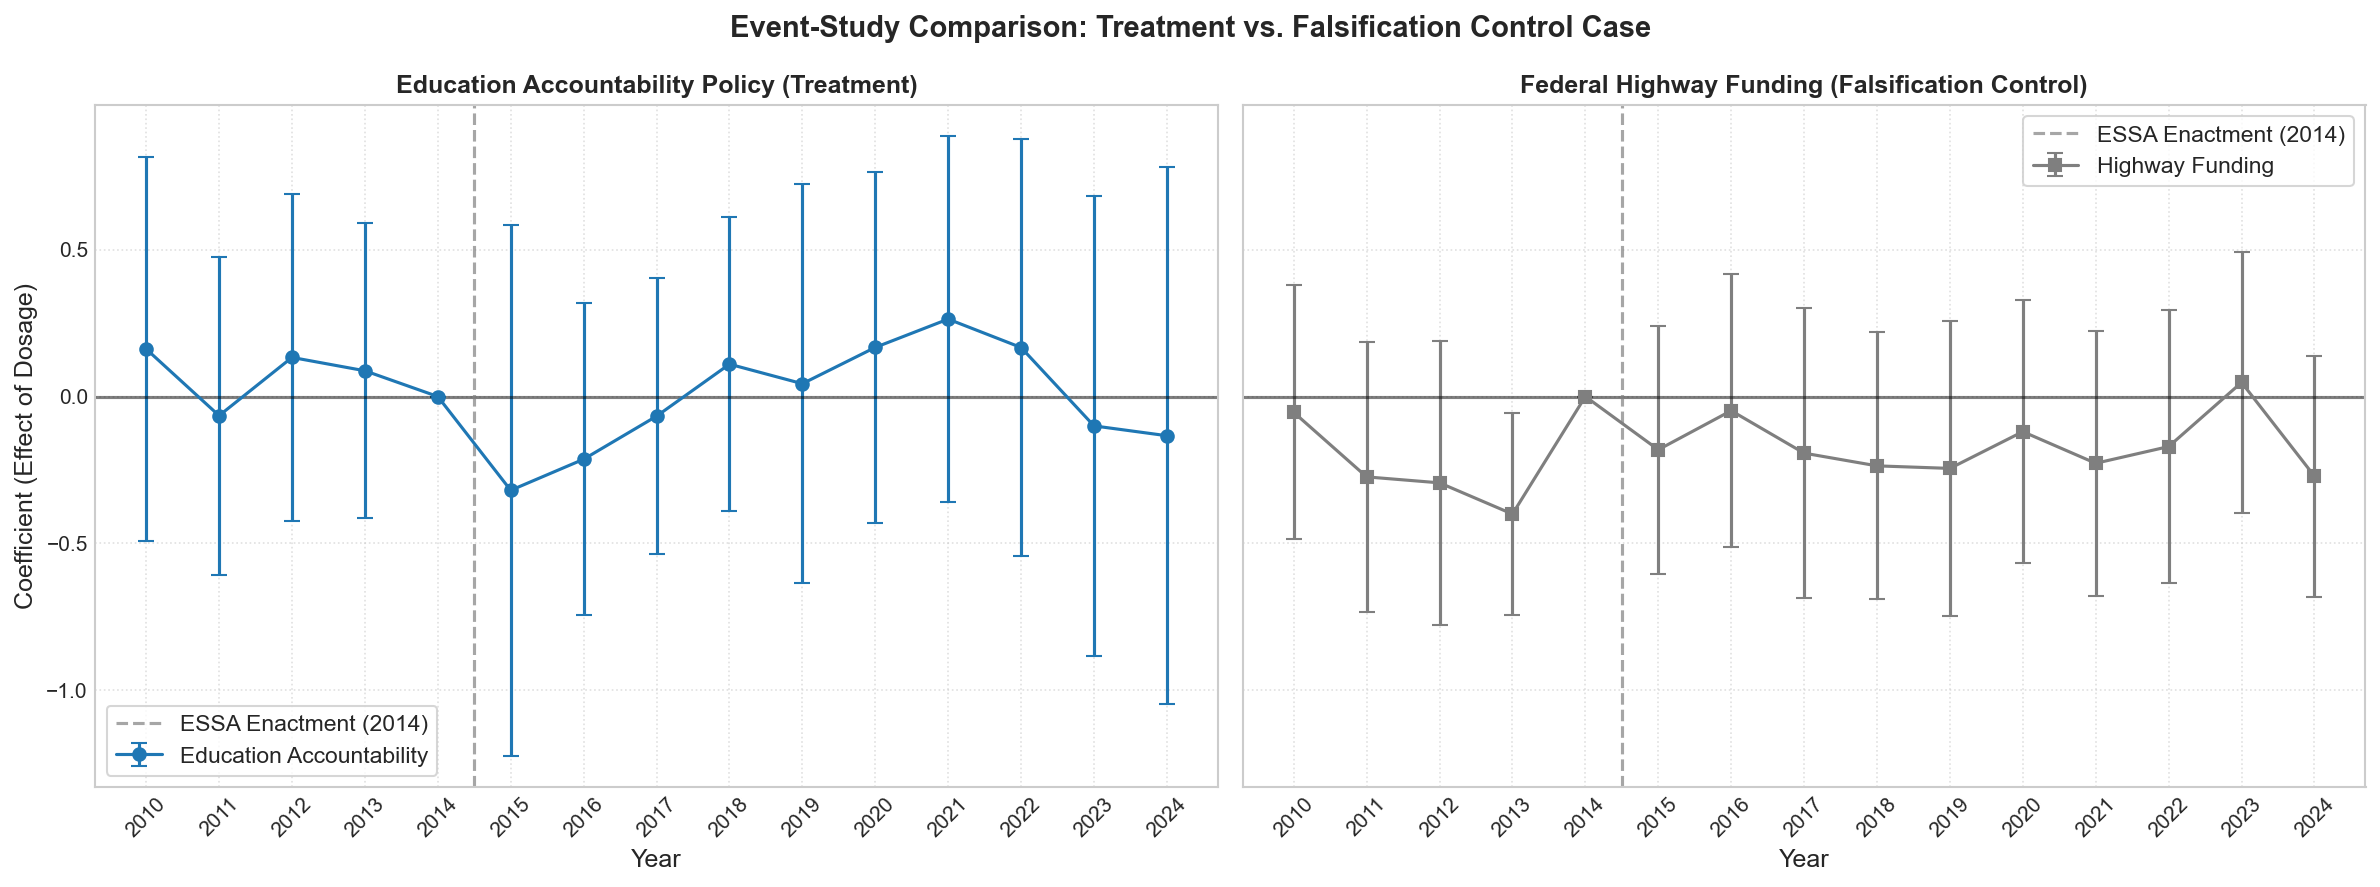

In [4]:
# 1. Calculate continuous dosage for highway funding (average pre-ESSA highway intensity 2010-2014)
pre_h_mean = df[df['year'] <= 2014].groupby('state')['highway_policy_intensity'].mean().reset_index()
pre_h_mean.rename(columns={'highway_policy_intensity': 'pre_h_dosage'}, inplace=True)
df_event_h = df.merge(pre_h_mean, on='state')

for y in event_years:
    if y != 2014:
        df_event_h[f'h_dosage_x_{y}'] = df_event_h['pre_h_dosage'] * (df_event_h['year'] == y).astype(int)

# Fit OLS for highway backlash
interaction_terms_h = ' + '.join([f'h_dosage_x_{y}' for y in event_years if y != 2014])
formula_h = f'highway_backlash ~ {interaction_terms_h} + gov_party_rep + trifecta + election_year + C(state) + C(year)'
model_h = smf.ols(formula_h, data=df_event_h).fit(cov_type='cluster', cov_kwds={'groups': df_event_h['state']})

coefs_h = []
ci_low_h = []
ci_high_h = []

for y in event_years:
    if y == 2014:
        coefs_h.append(0.0)
        ci_low_h.append(0.0)
        ci_high_h.append(0.0)
    else:
        var_name = f'h_dosage_x_{y}'
        coefs_h.append(model_h.params[var_name])
        ci = model_h.conf_int().loc[var_name]
        ci_low_h.append(ci[0])
        ci_high_h.append(ci[1])

# Plot Side-by-Side Event-Study Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Education
axes[0].errorbar(years, coefs, yerr=[[c - l for c, l in zip(coefs, ci_low)], [h - c for c, h in zip(coefs, ci_high)]],
                 fmt='o-', color='#1f77b4', ecolor='#1f77b4', elinewidth=1.5, capsize=4, ms=6, label='Education Accountability')
axes[0].axhline(0, color='black', linestyle='-', alpha=0.5)
axes[0].axvline(2014.5, color='gray', linestyle='--', alpha=0.7, label='ESSA Enactment (2014)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Coefficient (Effect of Dosage)')
axes[0].set_title('Education Accountability Policy (Treatment)', fontsize=12, fontweight='bold')
axes[0].set_xticks(event_years)
axes[0].set_xticklabels(event_years, rotation=45)
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Highway
axes[1].errorbar(years, coefs_h, yerr=[[c - l for c, l in zip(coefs_h, ci_low_h)], [h - c for c, h in zip(coefs_h, ci_high_h)]],
                 fmt='s-', color='#7f7f7f', ecolor='#7f7f7f', elinewidth=1.5, capsize=4, ms=6, label='Highway Funding')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.5)
axes[1].axvline(2014.5, color='gray', linestyle='--', alpha=0.7, label='ESSA Enactment (2014)')
axes[1].set_xlabel('Year')
axes[1].set_title('Federal Highway Funding (Falsification Control)', fontsize=12, fontweight='bold')
axes[1].set_xticks(event_years)
axes[1].set_xticklabels(event_years, rotation=45)
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Event-Study Comparison: Treatment vs. Falsification Control Case', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

C:\Users\admir\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


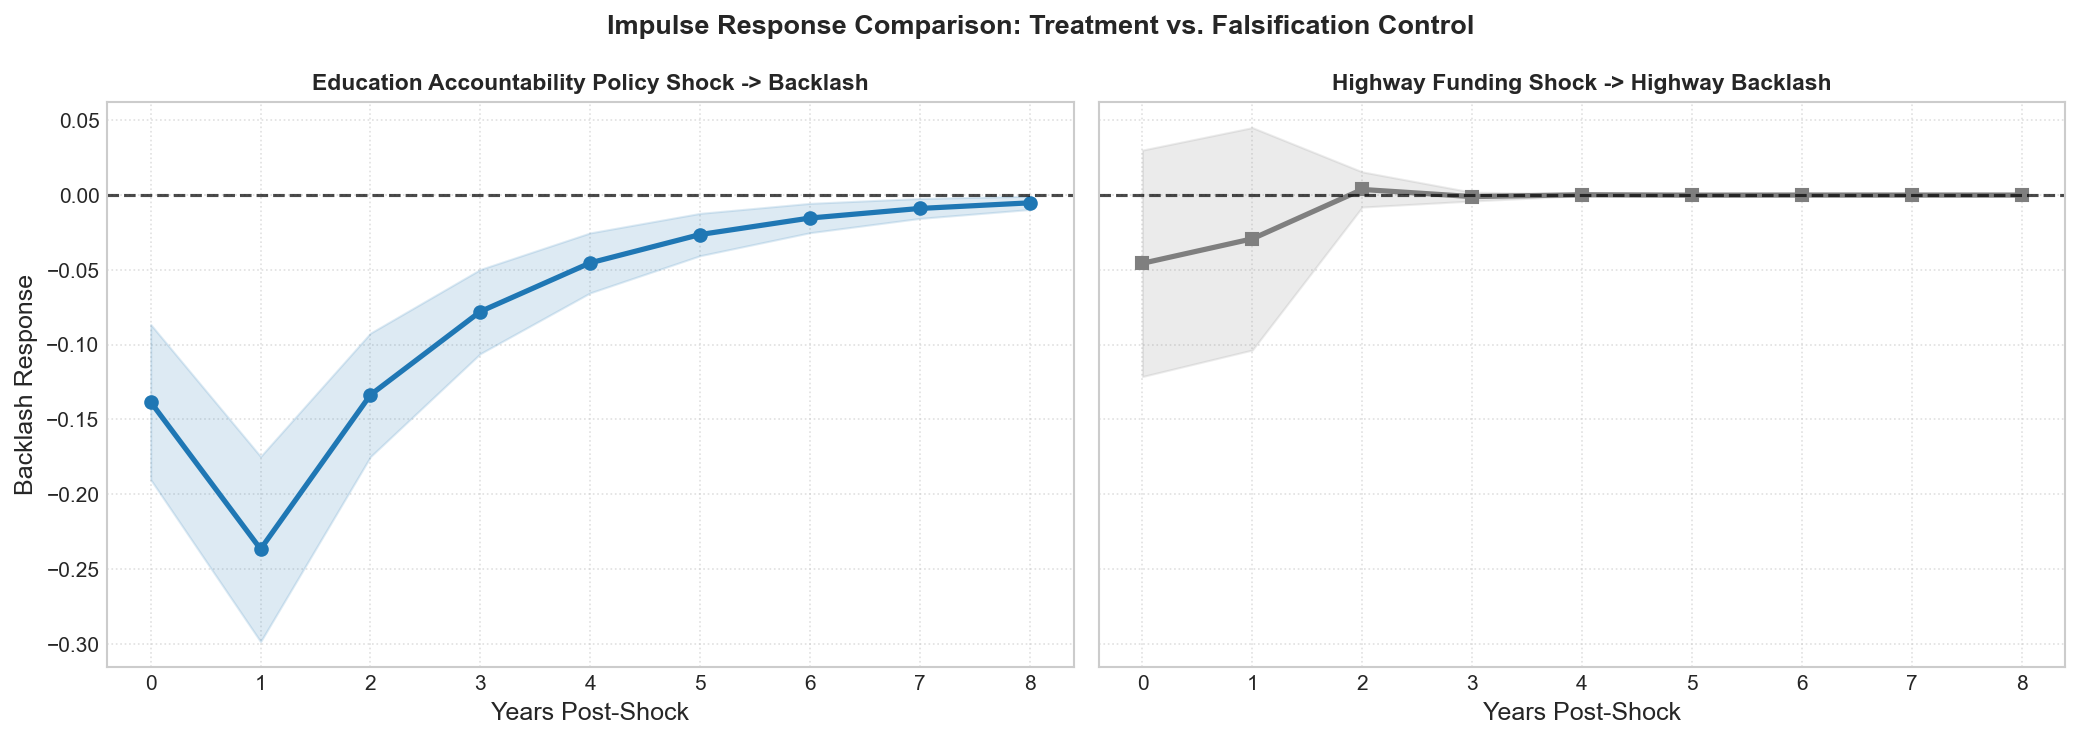

In [5]:
# 1. Transform variables for highway panel
df['delta_highway_policy'] = df.groupby('state')['highway_policy_intensity'].diff()
df_var_input_h = df[['state', 'year', 'delta_highway_policy', 'highway_backlash']].dropna().copy()
df_helmert_h = helmert_transform(df_var_input_h, ['delta_highway_policy', 'highway_backlash'])

# 2. Fit VAR(1) for highway
var_model_h = VAR(df_helmert_h[['delta_highway_policy', 'highway_backlash']])
var_results_h = var_model_h.fit(maxlags=1)
irf_h = var_results_h.irf(8)

# 3. Extract highway responses
resp_b_to_p_h = irf_h.orth_irfs[:, 1, 0]
se_b_to_p_h = irf_h.stderr(orth=True)[:, 1, 0]

# 4. Plot IRF Comparison side-by-side (Backlash response to policy shock)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Education
axes[0].plot(steps, resp_b_to_p, color='#1f77b4', lw=2.5, marker='o', label='Education IRF')
axes[0].fill_between(steps, resp_b_to_p - 1.96 * se_b_to_p, resp_b_to_p + 1.96 * se_b_to_p, color='#1f77b4', alpha=0.15)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title('Education Accountability Policy Shock -> Backlash', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Years Post-Shock')
axes[0].set_ylabel('Backlash Response')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Highway
axes[1].plot(steps, resp_b_to_p_h, color='#7f7f7f', lw=2.5, marker='s', label='Highway IRF')
axes[1].fill_between(steps, resp_b_to_p_h - 1.96 * se_b_to_p_h, resp_b_to_p_h + 1.96 * se_b_to_p_h, color='#7f7f7f', alpha=0.15)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Highway Funding Shock -> Highway Backlash', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Years Post-Shock')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Impulse Response Comparison: Treatment vs. Falsification Control', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Spline Breakpoint "Backlash Threshold" S-Curve
We execute an exploratory threshold spline analysis to locate the non-linear breakpoint in the relationship between the policy gap and backlash scores.

Optimal threshold knot (theta): -0.9499
R-squared with spline: 0.7034


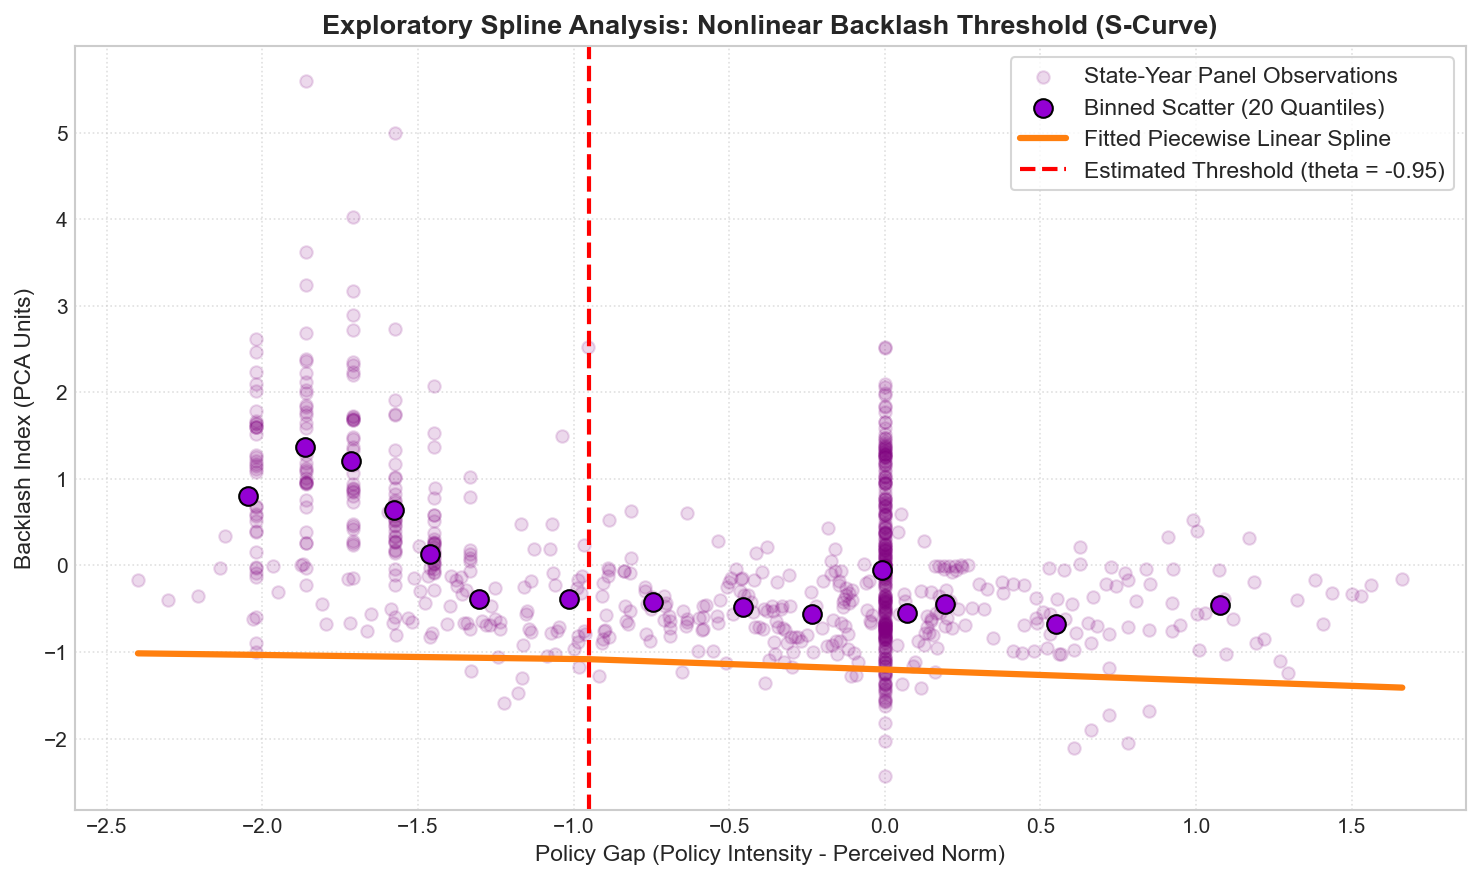

In [6]:
df_spline = df.dropna(subset=['backlash', 'policy_intensity', 'norm', 'gov_party_rep', 'trifecta', 'election_year', 'state', 'year']).copy()
df_spline['policy_gap'] = df_spline['policy_intensity'] - df_spline['norm']

# Grid search for the optimal breakpoint (knot) theta
p25 = df_spline['policy_gap'].quantile(0.25)
p75 = df_spline['policy_gap'].quantile(0.75)
best_theta = None
best_rsquared = -np.inf
best_model = None

thetas = np.linspace(p25, p75, 100)
for theta in thetas:
    df_spline['policy_gap_pos'] = np.maximum(0, df_spline['policy_gap'] - theta)
    fit = smf.ols('backlash ~ policy_gap + policy_gap_pos + gov_party_rep + trifecta + election_year + C(state) + C(year)', data=df_spline).fit()
    if fit.rsquared > best_rsquared:
        best_rsquared = fit.rsquared
        best_theta = theta
        best_model = fit

print(f'Optimal threshold knot (theta): {best_theta:.4f}')
print(f'R-squared with spline: {best_rsquared:.4f}')

# Plot raw data, binned scatter, and the fitted spline curve
gap_range = np.linspace(df_spline['policy_gap'].min(), df_spline['policy_gap'].max(), 300)
pred_y = best_model.params['Intercept'] + best_model.params['policy_gap'] * gap_range + best_model.params['policy_gap_pos'] * np.maximum(0, gap_range - best_theta)

# Create a binned scatter plot to make the trend clearer
df_spline['bin'] = pd.qcut(df_spline['policy_gap'], q=20, labels=False, duplicates='drop')
binned = df_spline.groupby('bin').agg({'policy_gap': 'mean', 'backlash': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(df_spline['policy_gap'], df_spline['backlash'], color='purple', alpha=0.15, label='State-Year Panel Observations')
plt.scatter(binned['policy_gap'], binned['backlash'], color='darkviolet', edgecolor='black', s=80, zorder=3, label='Binned Scatter (20 Quantiles)')
plt.plot(gap_range, pred_y, color='#ff7f0e', lw=3, label='Fitted Piecewise Linear Spline')
plt.axvline(best_theta, color='red', linestyle='--', lw=2, label=f'Estimated Threshold (theta = {best_theta:.2f})')

plt.xlabel('Policy Gap (Policy Intensity - Perceived Norm)', fontsize=11)
plt.ylabel('Backlash Index (PCA Units)', fontsize=11)
plt.title('Exploratory Spline Analysis: Nonlinear Backlash Threshold (S-Curve)', fontsize=13, fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()